# 05 – Feature Engineering: Variables de Ingreso

**Proyecto:** Encuesta Permanente de Empleo Nacional (EPEN)  
**Objetivo:** Crear nuevas variables derivadas del ingreso que capturen mejor las diferencias socioeconómicas relevantes para predecir la condición de desempleo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ─── Cargar datos balanceados ──────────────────────────────────────────────────
BALANCED_DIR = os.path.join('..', 'data', 'balanced')
try:
    X = pd.read_csv(os.path.join(BALANCED_DIR, 'X_train_balanced.csv'))
    y = pd.read_csv(os.path.join(BALANCED_DIR, 'y_train_balanced.csv')).squeeze()
except FileNotFoundError:
    np.random.seed(42)
    n = 1000
    X = pd.DataFrame({
        'edad': np.random.randint(14, 70, n),
        'ingreso_mensual': np.random.exponential(8000, n).round(2),
        'horas_trabajadas': np.random.randint(0, 60, n),
        'sexo_bin': np.random.randint(0, 2, n),
        'nivel_educativo_ord': np.random.randint(0, 6, n),
        'tipo_empleo_cod': np.random.choice([-1, 0, 1], n),
    })
    y = pd.Series(np.random.choice([0, 1], n, p=[0.50, 0.50]), name='target_desocupado')

df = X.copy()
df['target_desocupado'] = y.values
print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

Dataset cargado: 1,000 filas × 7 columnas


## 1. Transformación logarítmica del ingreso

El ingreso tiene distribución sesgada a la derecha; aplicar `log1p` la aproxima a una distribución normal.

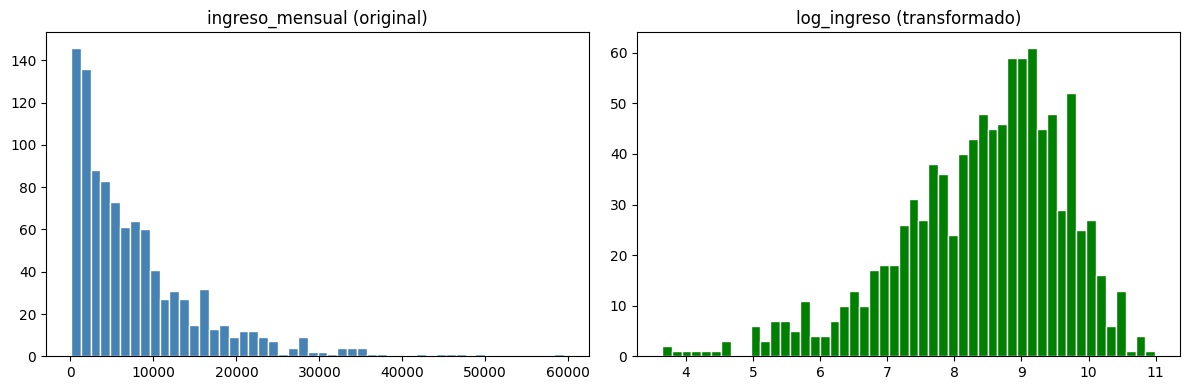

Variable creada: log_ingreso


In [2]:
if 'ingreso_mensual' in df.columns:
    df['log_ingreso'] = np.log1p(df['ingreso_mensual'].clip(lower=0))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(df['ingreso_mensual'], bins=50, color='steelblue', edgecolor='white')
    axes[0].set_title('ingreso_mensual (original)')
    axes[1].hist(df['log_ingreso'], bins=50, color='green', edgecolor='white')
    axes[1].set_title('log_ingreso (transformado)')
    plt.tight_layout()
    plt.show()
    print('Variable creada: log_ingreso')

## 2. Ingreso por hora trabajada

In [3]:
if 'ingreso_mensual' in df.columns and 'horas_trabajadas' in df.columns:
    # Evitar división por cero
    df['ingreso_por_hora'] = np.where(
        df['horas_trabajadas'] > 0,
        df['ingreso_mensual'] / (df['horas_trabajadas'] * 4.33),  # 4.33 semanas/mes
        0.0
    ).round(2)
    print('Variable creada: ingreso_por_hora')
    print(df['ingreso_por_hora'].describe())

Variable creada: ingreso_por_hora
count    1000.000000
mean      153.250170
std       392.913193
min         0.000000
25%        16.397500
50%        46.155000
75%       116.437500
max      4900.800000
Name: ingreso_por_hora, dtype: float64


## 3. Quintil de ingreso

In [4]:
if 'ingreso_mensual' in df.columns:
    df['quintil_ingreso'] = pd.qcut(
        df['ingreso_mensual'].clip(lower=0.01),
        q=5, labels=False, duplicates='drop'
    )
    print('Variable creada: quintil_ingreso')
    print(df['quintil_ingreso'].value_counts().sort_index())

Variable creada: quintil_ingreso
quintil_ingreso
0    200
1    200
2    200
3    200
4    200
Name: count, dtype: int64


## 4. Indicador de ingreso bajo

In [5]:
SALARIO_MINIMO = 2080  # Salario mínimo mensual de referencia (MXN)
if 'ingreso_mensual' in df.columns:
    df['ingreso_bajo'] = (df['ingreso_mensual'] < SALARIO_MINIMO).astype(int)
    print(f'Variable creada: ingreso_bajo (umbral: ${SALARIO_MINIMO:,} MXN)')
    print(f'Personas con ingreso bajo: {df["ingreso_bajo"].sum():,} ({df["ingreso_bajo"].mean()*100:.1f}%)')

Variable creada: ingreso_bajo (umbral: $2,080 MXN)
Personas con ingreso bajo: 240 (24.0%)


In [6]:
# Guardar dataset con nuevas features de ingreso
FE_DIR = os.path.join('..', 'data', 'feature_engineering')
os.makedirs(FE_DIR, exist_ok=True)
df.to_csv(os.path.join(FE_DIR, 'epen_fe_income.csv'), index=False)
nuevas = ['log_ingreso', 'ingreso_por_hora', 'quintil_ingreso', 'ingreso_bajo']
print('Nuevas variables de ingreso:', [c for c in nuevas if c in df.columns])
print('Dataset guardado: epen_fe_income.csv')

Nuevas variables de ingreso: ['log_ingreso', 'ingreso_por_hora', 'quintil_ingreso', 'ingreso_bajo']
Dataset guardado: epen_fe_income.csv
